The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

Install required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/content/sample_data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.shape

(284807, 31)

In [6]:
#check null values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
#check duplicates
df.duplicated().sum()

np.int64(1081)

In [8]:
df=df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(283726, 31)

In [11]:
#check class imbalance
df['Class'].value_counts()

,count
Class,
0,283253
1,473


#Check Fraud Distribution

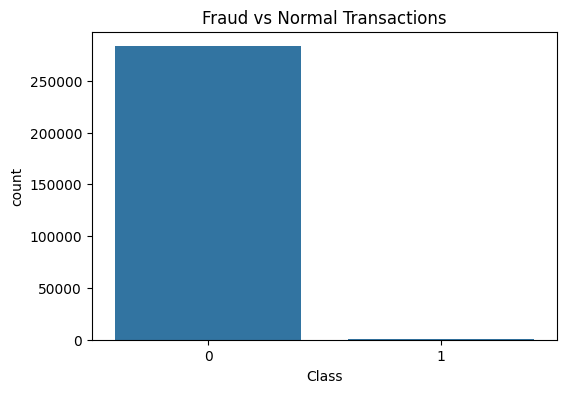

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Normal Transactions")
plt.show()

##Percentage of Fraud cases


In [13]:
fraud_percentage = (df['Class'].value_counts()[1] /len(df)) * 100

print(f"Fraud percentage: {fraud_percentage:.3f}%")

Fraud percentage: 0.167%


##Check Transaction Amount Distribution

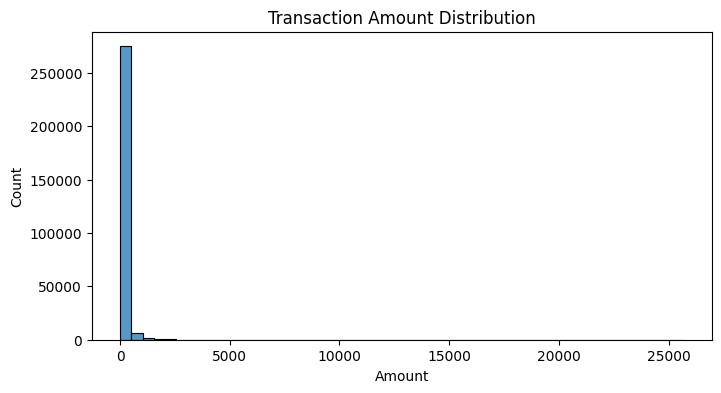

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'],bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

#Correlation analysis using heatmap

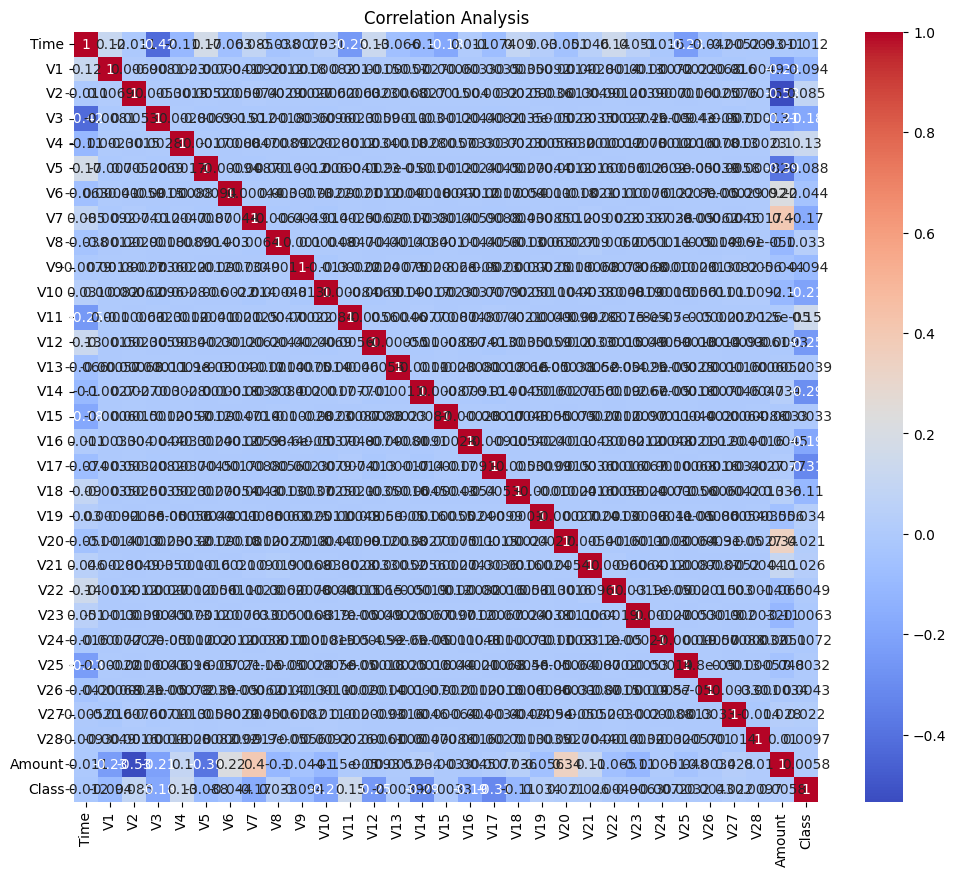

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()

#Separation of features

In [18]:
X=df.drop('Class',axis=1)
y=df['Class'] #target

In [19]:
print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


##Splitting the data


In [20]:
from sklearn.model_selection import  train_test_split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

##Feature scaling


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])

X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

In [24]:
X_train[['Time','Amount']].head()

,Time,Amount
226238,1.045499,-0.229434
134253,-0.298690,-0.331197
186465,0.678397,-0.298809
149493,-0.074929,-0.289247
18461,-1.376728,-0.261985


In [25]:
#Class distribution
print(y_train.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


###SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) is a popular machine learning algorithm used to handle imbalanced datasets. It prevents models from becoming biased toward the majority class by generating new, synthetic data points for the minority class through interpolation rather than simple duplication

#Apply SMOTE

In [26]:
from imblearn.over_sampling import SMOTE

In [27]:
smote=SMOTE(random_state=42)
X_train_resampled,y_train_resampled=smote.fit_resample(X_train,y_train)
X_train_resampled.shape,y_train_resampled.shape

((453204, 30), (453204,))

In [28]:
y_train_resampled.value_counts()

,count
Class,
0,226602
1,226602


##Model Building
1. Logistic Regression
2. Random Forest
3. XGBoost

##Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [37]:
lr_model=LogisticRegression()
lr_model.fit(X_train_resampled,y_train_resampled)

LogisticRegression()

In [38]:
y_pred=lr_model.predict(X_test)

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



#ROC-AUC score

In [41]:
lr_probability = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC:",roc_auc_score(y_test,lr_probability))

ROC-AUC: 0.9618957810936585


##Random Forest Classifier

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

In [43]:
rf_model.fit(X_train_resampled,y_train_resampled)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [44]:
y_pred=rf_model.predict(X_test)

In [45]:
#classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [46]:
#ROC-AUC score
rf_probability = rf_model.predict_proba(X_test)[:,1]
print("ROC-AUC:",roc_auc_score(y_test,rf_probability))

ROC-AUC: 0.9656055683506306


##XGBoost

In [47]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05,random_state=42,eval_metric='logloss')

In [48]:
xgb_model.fit(X_train_resampled,y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
xgb_prediction = xgb_model.predict(X_test)

In [50]:
#classification report
print(classification_report(y_test,xgb_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.26      0.84      0.40        95

    accuracy                           1.00     56746
   macro avg       0.63      0.92      0.70     56746
weighted avg       1.00      1.00      1.00     56746



In [51]:
#ROC-AUC score
xgb_probability = xgb_model.predict_proba(X_test)[:,1]
print("ROC-AUC:",roc_auc_score(y_test,xgb_probability))

ROC-AUC: 0.9735767195079011


##Compare Models

In [52]:
results = {
    "Logistic Regression": roc_auc_score(y_test, lr_probability),
    "Random Forest": roc_auc_score(y_test, rf_probability),
    "XGBoost": roc_auc_score(y_test, xgb_probability)
}


for model, score in results.items():
    print(model, ":", score)

Logistic Regression : 0.9618957810936585
Random Forest : 0.9656055683506306
XGBoost : 0.9735767195079011


##Conclusion
XGBoost model gives better results.